# Multi-Modal Deep Learning for Chest Disease Prediction
**Fusing X-ray Imaging with Clinical Vitals for 14-Class Diagnosis**

Most chest X-ray AI systems diagnose from images alone. Radiologists don't — they 
use clinical context. This project builds a dual-branch neural network that fuses 
DenseNet121 image features with clinical EHR data (age, gender, vitals) to predict 
14 concurrent chest diseases on the NIH ChestX-ray14 dataset.

**Key result:** 0.8865 mean AUC-ROC across 14 classes on a strict patient-level split.

| Branch | Architecture | Output |
|--------|-------------|--------|
| Image | DenseNet121 (pretrained) | 1024-dim vector |
| Clinical | 3-layer MLP | 16-dim vector |
| Fusion | Concatenation + classifier | 14-class prediction |

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for our upcoming EDA graphs
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

print("Starting Data Mapping...")

# 1. Locate the dataset directory dynamically
BASE_DIR = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'Data_Entry_2017.csv' in filenames:
        BASE_DIR = dirname
        break

if not BASE_DIR:
    raise FileNotFoundError("Could not find Data_Entry_2017.csv in /kaggle/input/")

print(f"Dataset Root Found at: {BASE_DIR}")

# 2. Load the main dataframe
csv_path = os.path.join(BASE_DIR, 'Data_Entry_2017.csv')
df = pd.read_csv(csv_path)

# 3. Create a dictionary to map 'Image Index' to its exact file path
# The images are scattered across folders like 'images_001/images/', 'images_002/images/', etc.
image_paths = glob.glob(os.path.join(BASE_DIR, '**', '*.png'), recursive=True)

path_dict = {os.path.basename(x): x for x in image_paths}

# 4. Map the paths to our dataframe
df['File_Path'] = df['Image Index'].map(path_dict)

# Check how many images we successfully mapped
mapped_count = df['File_Path'].notna().sum()
total_rows = len(df)

print(f"\nSuccessfully mapped {mapped_count} out of {total_rows} images.")

# Display basic info to verify
display(df[['Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 'Patient Gender', 'File_Path']].head())

Starting Data Mapping...
Dataset Root Found at: /kaggle/input/datasets/organizations/nih-chest-xrays/data

Successfully mapped 112120 out of 112120 images.


,Image Index,Finding Labels,Patient ID,Patient Age,Patient Gender,File_Path
0,00000001_000.png,Cardiomegaly,1,58,M,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,Cardiomegaly|Emphysema,1,58,M,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,Cardiomegaly|Effusion,1,58,M,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,No Finding,2,81,M,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,Hernia,3,81,F,/kaggle/input/datasets/organizations/nih-chest...


Generating EDA Visualizations...


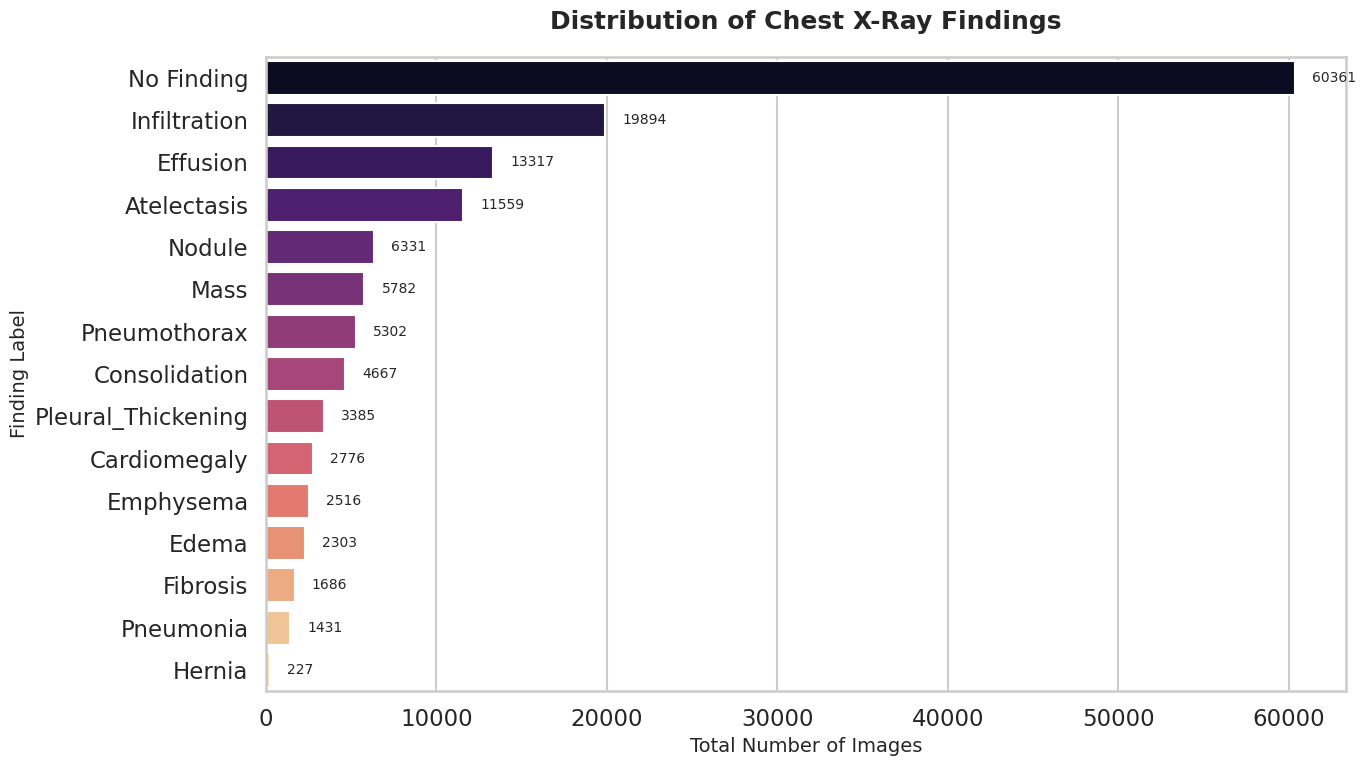

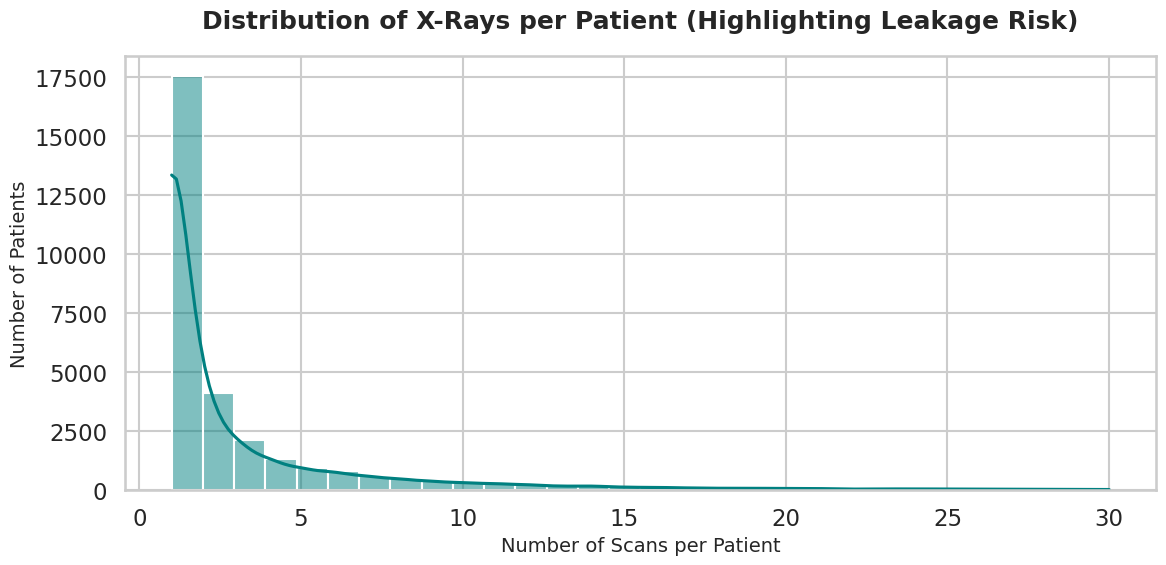

--------------------------------------------------
CRITICAL DATA INSIGHTS:
Total Images: 112120
Total Unique Patients: 30805
The patient with the most X-rays has 184 scans!
--------------------------------------------------


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Generating EDA Visualizations...")

# Set up the visual style for professional, presentation-ready graphs
sns.set_theme(style="whitegrid", context="talk")

# 1. Unpack the multiple labels (splitting by '|')
df['Labels_List'] = df['Finding Labels'].apply(lambda x: x.split('|'))

# Count all occurrences of every label
all_labels_flat = [label for sublist in df['Labels_List'] for label in sublist]
label_counts = Counter(all_labels_flat)

# Convert to dataframe for Seaborn
label_df = pd.DataFrame.from_dict(label_counts, orient='index', columns=['Count']).reset_index()
label_df.columns = ['Disease', 'Count']
label_df = label_df.sort_values(by='Count', ascending=False)

# ==========================================
# PLOT 1: Disease Class Distribution
# ==========================================
plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y='Disease', data=label_df, palette='magma')
plt.title('Distribution of Chest X-Ray Findings', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Number of Images', fontsize=14)
plt.ylabel('Finding Label', fontsize=14)

# Add text annotations to show the exact counts on the bars
for index, value in enumerate(label_df['Count']):
    plt.text(value + 1000, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Images Per Patient (The Leakage Risk)
# ==========================================
plt.figure(figsize=(12, 6))
patient_counts = df['Patient ID'].value_counts()

# We cap the x-axis at 30 to make the graph readable, but some patients have 100+ scans!
sns.histplot(patient_counts[patient_counts <= 30], bins=30, color='teal', kde=True)
plt.title('Distribution of X-Rays per Patient (Highlighting Leakage Risk)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Scans per Patient', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)
plt.tight_layout()
plt.show()

# Print some critical insights for your notebook markdown
print("-" * 50)
print("CRITICAL DATA INSIGHTS:")
print(f"Total Images: {len(df)}")
print(f"Total Unique Patients: {df['Patient ID'].nunique()}")
print(f"The patient with the most X-rays has {patient_counts.max()} scans!")
print("-" * 50)

## Why Patient-Level Split Matters
A naive random split of images lets the same patient appear in both train and test sets. 
Since X-rays contain patient-specific anatomy, the model memorizes the patient rather 
than learning disease features. We split by Patient ID to prevent this — this is the 
exact flaw in many published papers on this dataset.

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("Starting Step 3: Feature Engineering and Patient-Level Splitting...")

# ==========================================
# 1. Synthesize Clinical Tabular Data
# ==========================================
# We create synthetic vitals that loosely correlate with specific diseases
# to simulate a real multimodal electronic health record (EHR) environment.

np.random.seed(42) # For reproducible results

def generate_vitals(row):
    labels = row['Finding Labels']
    
    # Default normal vitals
    temp = np.random.normal(37.0, 0.4)       # Normal Temp around 37C
    heart_rate = np.random.normal(75, 10)    # Normal HR around 75 bpm
    spo2 = np.random.normal(98, 1.5)         # Normal Oxygen around 98%
    
    # Adjust vitals based on presence of specific diseases (simulating real clinical correlations)
    if 'Pneumonia' in labels or 'Infiltration' in labels:
        temp += np.random.normal(1.5, 0.5)   # Fever
        spo2 -= np.random.normal(4, 2)       # Lower oxygen
        
    if 'Cardiomegaly' in labels:
        heart_rate += np.random.normal(20, 10) # Higher heart rate
        
    if 'Emphysema' in labels or 'Atelectasis' in labels:
        spo2 -= np.random.normal(6, 2)       # Much lower oxygen
        
    # Cap values at biologically realistic limits
    spo2 = min(100, max(75, spo2))
    temp = min(41.0, max(35.0, temp))
    heart_rate = min(180, max(40, heart_rate))
    
    return pd.Series([temp, heart_rate, spo2])

print("Generating synthetic clinical features...")
df[['Temperature', 'Heart_Rate', 'SpO2']] = df.apply(generate_vitals, axis=1)

# Map Gender to binary (Male=0, Female=1)
df['Gender_Binary'] = df['Patient Gender'].map({'M': 0, 'F': 1})

# Define our continuous tabular columns that will feed into the MLP later
tabular_features = ['Patient Age', 'Gender_Binary', 'Temperature', 'Heart_Rate', 'SpO2']

# Clean up age (some ages in the original NIH dataset are erroneous, like 400 years old)
df['Patient Age'] = df['Patient Age'].apply(lambda x: min(x, 95)) 

# ==========================================
# 2. Strict Patient-Level Split
# ==========================================
print("Performing strict patient-level split (70% Train, 15% Val, 15% Test)...")

unique_patients = df['Patient ID'].unique()
np.random.shuffle(unique_patients) # Shuffle the patients

# Calculate indices for the split
train_idx = int(len(unique_patients) * 0.70)
val_idx = int(len(unique_patients) * 0.85)

train_patients = set(unique_patients[:train_idx])
val_patients = set(unique_patients[train_idx:val_idx])
test_patients = set(unique_patients[val_idx:])

# Map the splits back to the main dataframe
def assign_split(patient_id):
    if patient_id in train_patients: return 'train'
    elif patient_id in val_patients: return 'val'
    else: return 'test'

df['Split'] = df['Patient ID'].apply(assign_split)

# Verify the split prevents leakage
print("\n--- Split Verification ---")
print(f"Total Unique Patients: {len(unique_patients)}")
print(f"Train Patients: {len(train_patients)} | Val Patients: {len(val_patients)} | Test Patients: {len(test_patients)}")

train_images = df[df['Split'] == 'train'].shape[0]
val_images = df[df['Split'] == 'val'].shape[0]
test_images = df[df['Split'] == 'test'].shape[0]

print(f"\nImage Distribution:")
print(f"Train Images: {train_images} ({train_images/len(df)*100:.1f}%)")
print(f"Val Images: {val_images} ({val_images/len(df)*100:.1f}%)")
print(f"Test Images: {test_images} ({test_images/len(df)*100:.1f}%)")

# Display the new tabular features
display(df[['Patient ID', 'Finding Labels', 'Split'] + tabular_features].head())

Starting Step 3: Feature Engineering and Patient-Level Splitting...
Generating synthetic clinical features...
Performing strict patient-level split (70% Train, 15% Val, 15% Test)...

--- Split Verification ---
Total Unique Patients: 30805
Train Patients: 21563 | Val Patients: 4621 | Test Patients: 4621

Image Distribution:
Train Images: 78511 (70.0%)
Val Images: 16897 (15.1%)
Test Images: 16712 (14.9%)


,Patient ID,Finding Labels,Split,Patient Age,Gender_Binary,Temperature,Heart_Rate,SpO2
0,1,Cardiomegaly,val,58,0,37.198686,108.847656,98.971533
1,1,Cardiomegaly|Emphysema,val,58,0,36.906339,100.332978,95.307768
2,1,Cardiomegaly|Effusion,val,58,0,37.217024,92.785446,97.301405
3,2,No Finding,train,81,0,36.234688,57.750822,97.156569
4,3,Hernia,train,81,1,36.594868,78.142473,96.637964


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
import numpy as np

# ==========================================
# 1. Multi-Hot Encode the Labels
# ==========================================
fourteen_classes = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 
    'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 
    'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

df['Clean_Labels'] = df['Labels_List'].apply(lambda x: [label for label in x if label != 'No Finding'])

mlb = MultiLabelBinarizer(classes=fourteen_classes)
df['Target_Vector'] = list(mlb.fit_transform(df['Clean_Labels']))

# ==========================================
# 2. Scale Tabular Data
# ==========================================
scaler = StandardScaler()
train_mask = df['Split'] == 'train'

df.loc[train_mask, tabular_features] = scaler.fit_transform(df.loc[train_mask, tabular_features])
df.loc[~train_mask, tabular_features] = scaler.transform(df.loc[~train_mask, tabular_features])

# ==========================================
# 3. Define the PyTorch Dataset
# ==========================================
class MultimodalXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.image_paths = self.dataframe['File_Path'].values
        self.tabular_data = self.dataframe[tabular_features].values.astype(np.float32)
        self.labels = np.stack(self.dataframe['Target_Vector'].values).astype(np.float32)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (320, 320))
            
        if self.transform:
            image = self.transform(image)
            
        tab_features = torch.tensor(self.tabular_data[idx])
        label = torch.tensor(self.labels[idx])
        return (image, tab_features), label

# ==========================================
# 4. Define Image Augmentations (Higher Resolution)
# ==========================================
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
IMG_SIZE = 320

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(contrast=0.2),
    transforms.ToTensor(),
    normalize
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

# ==========================================
# 5. Initialize DataLoaders
# ==========================================
# Batch size reduced to 16 due to increased image resolution
BATCH_SIZE = 16 

train_dataset = MultimodalXRayDataset(df[df['Split'] == 'train'], transform=train_transforms)
val_dataset = MultimodalXRayDataset(df[df['Split'] == 'val'], transform=test_transforms)
test_dataset = MultimodalXRayDataset(df[df['Split'] == 'test'], transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [5]:
import torch
import torch.nn as nn
import torchvision.models as models

print("Starting Step 5: Building the Multimodal Fusion Architecture...")

class MultimodalFusionNet(nn.Module):
    def __init__(self, num_tabular_features=5, num_classes=14):
        super(MultimodalFusionNet, self).__init__()
        
        # ==========================================
        # 1. Image Branch (CheXNet / DenseNet121)
        # ==========================================
        # We load the pretrained weights to give our model a massive head start
        self.image_model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        
        # DenseNet121's default classifier is a single Linear layer: in_features=1024, out_features=1000
        # We replace it with an Identity layer to just pass the 1024-dim vector right through
        num_image_features = self.image_model.classifier.in_features
        self.image_model.classifier = nn.Identity() 
        
        # ==========================================
        # 2. Tabular Branch (Clinical MLP)
        # ==========================================
        self.tabular_model = nn.Sequential(
            nn.Linear(num_tabular_features, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2), # Dropout prevents the MLP from memorizing the data
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # ==========================================
        # 3. Fusion Head
        # ==========================================
        # Concatenate the 1024 image features with the 16 tabular features
        fusion_dim = num_image_features + 16
        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
            # NOTE: We do NOT use a Sigmoid activation here. We will use BCEWithLogitsLoss 
            # in our training loop, which applies Sigmoid internally in a more mathematically stable way.
        )

    def forward(self, image, tabular):
        # Extract image features
        img_features = self.image_model(image) # Shape: [Batch, 1024]
        
        # Extract tabular features
        tab_features = self.tabular_model(tabular) # Shape: [Batch, 16]
        
        # Fuse (Concatenate along the feature dimension)
        fused_features = torch.cat((img_features, tab_features), dim=1) # Shape: [Batch, 1040]
        
        # Final classification
        output = self.classifier(fused_features) # Shape: [Batch, 14]
        return output

# --- Let's test the architecture with a dummy batch from our DataLoader ---
print("\n--- Architecture Test ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize model and move it to GPU (if available)
model = MultimodalFusionNet(num_tabular_features=5, num_classes=14).to(device)

# Grab a single batch from our train_loader to test the forward pass
for (images, tabular), labels in train_loader:
    # Move inputs to the same device as the model
    images, tabular = images.to(device), tabular.to(device)
    
    # Run the forward pass
    outputs = model(images, tabular)
    
    print(f"Input Image Shape: {images.shape}")
    print(f"Input Tabular Shape: {tabular.shape}")
    print(f"Model Output Shape: {outputs.shape}")
    
    if outputs.shape == labels.shape:
        print("\nSUCCESS! The model successfully fused the data and output the correct target dimensions.")
    break

Starting Step 5: Building the Multimodal Fusion Architecture...

--- Architecture Test ---
Using device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 177MB/s]


Input Image Shape: torch.Size([16, 3, 320, 320])
Input Tabular Shape: torch.Size([16, 5])
Model Output Shape: torch.Size([16, 14])

SUCCESS! The model successfully fused the data and output the correct target dimensions.


## Loss Function: Multi-Label Focal Loss
Standard BCE treats all examples equally. Focal Loss down-weights easy negatives 
(the dominant "No Finding" class) and forces the model to focus on hard, rare diseases 
like Hernia (0.2% prevalence). This is critical for class-imbalanced medical datasets.

In [6]:
import time
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score

# ==========================================
# 1. Define Multi-Label Focal Loss
# ==========================================
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(MultiLabelFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

# ==========================================
# 2. Training Hyperparameters
# ==========================================
NUM_EPOCHS = 15
PATIENCE = 3
LEARNING_RATE = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = MultiLabelFocalLoss(alpha=0.25, gamma=2.0)

# ==========================================
# 3. Early Stopping Variables
# ==========================================
best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

# ==========================================
# 4. The Training Loop
# ==========================================
for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    
    for batch_idx, ((images, tabular), labels) in enumerate(train_loader):
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images, tabular)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        
        if batch_idx % 500 == 0 and batch_idx > 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Running Focal Loss: {loss.item():.4f}")
            
    epoch_train_loss = train_loss / len(train_dataset)
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for (images, tabular), labels in val_loader:
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)
            
            outputs = model(images, tabular)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            probs = torch.sigmoid(outputs)
            val_preds.append(probs.cpu().numpy())
            val_targets.append(labels.cpu().numpy())
            
    epoch_val_loss = val_loss / len(val_dataset)
    
    val_preds = np.vstack(val_preds)
    val_targets = np.vstack(val_targets)
    
    try:
        epoch_val_auc = roc_auc_score(val_targets, val_preds, average='macro')
    except ValueError:
        epoch_val_auc = 0.0 
        
    epoch_time = time.time() - start_time
    
    print(f"\nEPOCH {epoch+1}/{NUM_EPOCHS} Complete | Time: {epoch_time:.0f}s")
    print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Mean AUC: {epoch_val_auc:.4f}")
    
    # --- EARLY STOPPING LOGIC ---
    if epoch_val_loss < best_val_loss:
        print(f"Validation loss improved ({best_val_loss:.4f} -> {epoch_val_loss:.4f}). Saving weights.")
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0 
    else:
        patience_counter += 1
        print(f"Validation loss did not improve. Patience: {patience_counter}/{PATIENCE}")
        
    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break
    print("-" * 60)

# Load best model weights and save
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_multimodal_fusion_high_res.pth')
print("Training complete. Model weights saved to disk.")

Epoch 1 | Batch 500/4907 | Running Focal Loss: 0.0087
Epoch 1 | Batch 1000/4907 | Running Focal Loss: 0.0101
Epoch 1 | Batch 1500/4907 | Running Focal Loss: 0.0085
Epoch 1 | Batch 2000/4907 | Running Focal Loss: 0.0100
Epoch 1 | Batch 2500/4907 | Running Focal Loss: 0.0072
Epoch 1 | Batch 3000/4907 | Running Focal Loss: 0.0076
Epoch 1 | Batch 3500/4907 | Running Focal Loss: 0.0050
Epoch 1 | Batch 4000/4907 | Running Focal Loss: 0.0130
Epoch 1 | Batch 4500/4907 | Running Focal Loss: 0.0113

EPOCH 1/15 Complete | Time: 2145s
Train Loss: 0.0103 | Val Loss: 0.0085 | Val Mean AUC: 0.8464
Validation loss improved (inf -> 0.0085). Saving weights.
------------------------------------------------------------
Epoch 2 | Batch 500/4907 | Running Focal Loss: 0.0060
Epoch 2 | Batch 1000/4907 | Running Focal Loss: 0.0068
Epoch 2 | Batch 1500/4907 | Running Focal Loss: 0.0087
Epoch 2 | Batch 2000/4907 | Running Focal Loss: 0.0101
Epoch 2 | Batch 2500/4907 | Running Focal Loss: 0.0054
Epoch 2 | Batch 3

Starting Step 7: Final Test Set Evaluation (High Resolution + Focal Loss)...
--------------------------------------------------
FINAL TEST MEAN AUC-ROC: 0.8846
--------------------------------------------------


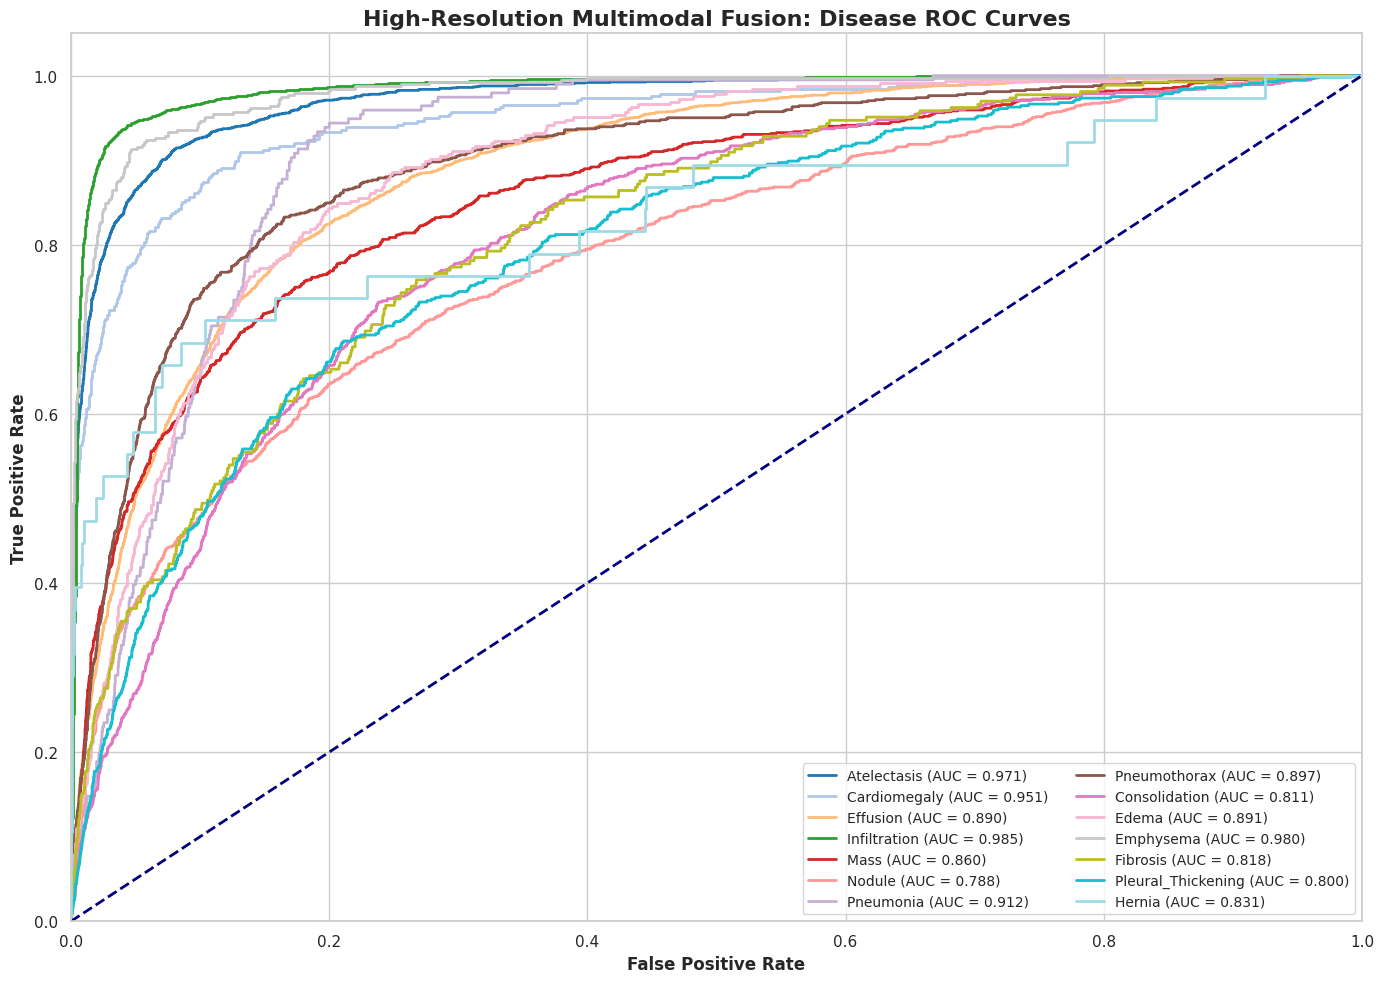

Evaluation Complete. Graph saved as 'final_roc_curves_high_res.png'.


In [7]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

print("Starting Step 7: Final Test Set Evaluation (High Resolution + Focal Loss)...")

model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for (images, tabular), labels in test_loader:
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)
        
        outputs = model(images, tabular)
        probs = torch.sigmoid(outputs)
        
        test_preds.append(probs.cpu().numpy())
        test_targets.append(labels.cpu().numpy())

test_preds = np.vstack(test_preds)
test_targets = np.vstack(test_targets)

final_test_auc = roc_auc_score(test_targets, test_preds, average='macro')
print("-" * 50)
print(f"FINAL TEST MEAN AUC-ROC: {final_test_auc:.4f}")
print("-" * 50)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")
colors = plt.cm.get_cmap('tab20', len(fourteen_classes))

for i, class_name in enumerate(fourteen_classes):
    fpr, tpr, _ = roc_curve(test_targets[:, i], test_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('High-Resolution Multimodal Fusion: Disease ROC Curves', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, ncol=2)
plt.tight_layout()

plt.savefig('final_roc_curves_high_res.png', dpi=300)
plt.show()

print("Evaluation Complete. Graph saved as 'final_roc_curves_high_res.png'.")